In [1]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

In [6]:
def getCSV(csv):
    raw_df = pd.read_csv(csv)
    return raw_df
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\GardaDiscrimination.csv')
print(set(list(df["Ethnicity"])))

{'Other ethnic backgrounds', 'Other white ethnic backgrounds', 'Asian Irish/Asian Indian/Chinese/other Asian background', 'All ethnicities', 'White Irish', 'Ethnicity not stated', 'Black Irish/black African/other black background', 'Irish Travellers/Roma'}


In [13]:
def changeNames(name):
    switch = {
        "Other ethnic backgrounds": "Other",
        "Other white ethnic backgrounds": "Other White",
        "Asian Irish/Asian Indian/Chinese/other Asian background": "Asian",
        "Ethnicity not stated": "Ethnicity not \nstated",
        "Black Irish/black African/other black background": "Black",
        "Irish Travellers/Roma": "Travellers\n/Roma"
    }
    if name not in switch:
        return name
    else:
        return switch[name]

In [15]:
filtered_df = df[df['Experienced discrimination interacting with An Garda Síochána']=='Yes']
filtered_df = filtered_df[filtered_df['Ethnicity']]
filtered_df['Ethnicity'] = filtered_df['Ethnicity'].apply(changeNames)
print(filtered_df)

                                     Statistic Label  Year  \
0  Individuals who experienced discrimination int...  2024   
1  Individuals who experienced discrimination int...  2024   
2  Individuals who experienced discrimination int...  2024   
3  Individuals who experienced discrimination int...  2024   
4  Individuals who experienced discrimination int...  2024   
5  Individuals who experienced discrimination int...  2024   
6  Individuals who experienced discrimination int...  2024   
7  Individuals who experienced discrimination int...  2024   

  Experienced discrimination interacting with An Garda Síochána  \
0                                                Yes              
1                                                Yes              
2                                                Yes              
3                                                Yes              
4                                                Yes              
5                                      

C:\Users\Tom\AppData\Local\Temp\ipykernel_18152\968460694.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Ethnicity'] = filtered_df['Ethnicity'].apply(changeNames)


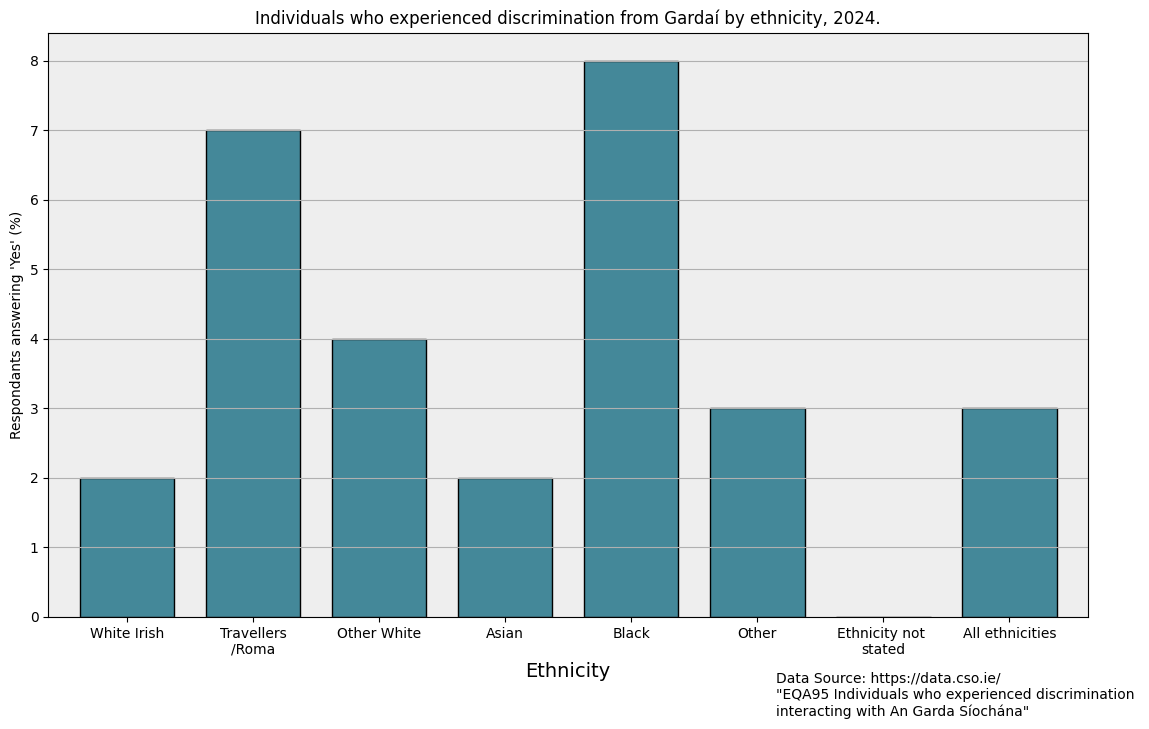

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

filtered_df.plot(x="Ethnicity", y="VALUE", kind="bar", width=.75, edgecolor="black", color="#489", ax=ax)

title_string = "Individuals who experienced discrimination from Gardaí by ethnicity, 2024."

plt.title(title_string)
plt.xlabel('Ethnicity', fontsize=14)
plt.ylabel('Respondants answering \'Yes\' (%)')
plt.xticks(rotation=0) 
ax.set_facecolor('#EEEEEE') 
# ax.set_ylim(0,)
ax.legend().set_visible(False)
plt.grid(True, axis="y")

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.7, -0.17, "Data Source: https://data.cso.ie/ \n\"EQA95 Individuals who experienced discrimination \ninteracting with An Garda Síochána\"", ha='left', transform=ax.transAxes)

save_fig = 'GardaDiscrimination.png'
plt.savefig(save_fig)

# Show the plot
plt.show()
